In [1]:
!pip install torch torchvision pytorch-lightning matplotlib


In [2]:
import zipfile
import os

# Path to the zip file and the target extraction directory
zip_path = '/teamspace/studios/this_studio/data/Brain_Cancer raw MRI data.zip'
extract_dir = 'data'  # Destination directory to unzip to

# Unzip if not already extracted
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

# Updated data_dir path for your DataModule
data_path = '/teamspace/studios/this_studio/.lightning_studio/data/Brain_Cancer' # If 'class_1', 'class_2', etc., are directly under 'data'


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import random_split, DataLoader

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Check if classes are loaded correctly
print("Class Names:", dataset.classes)  # Should output: ['brain_glioma', 'brain_menin', 'brain_tumor']


# Split dataset into train (60%), validation (20%), and test (20%)
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# DenseNet121 Model setup
model = models.densenet121(pretrained=True)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 3)  # Adjust output layer for 3 classes
model = model.to(device)



# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training and validation metrics storage
train_losses = []
val_losses = []
val_accuracies = []

# Training loop
num_epochs = 25
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)

        # Forward pass
        outputs = model(data)
        loss = criterion(outputs, targets)
        running_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Calculate average loss for training
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation step
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            # Accuracy calculation
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

# Test the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Save the model
save_path = "/teamspace/studios/this_studio/.lightning_studio/brain_cancer_densenet121.pth"  # Set your lightning.ai save path here
os.makedirs(os.path.dirname(save_path), exist_ok=True)  # Ensure directory exists
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Save metrics for plotting
metrics_path = "/teamspace/studios/this_studio/.lightning_studio/densenet121_metrics.pth"  # Save path for metrics
torch.save({
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies,
}, metrics_path)
print(f"Metrics saved to {metrics_path}")


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/zeus/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


Class Names: ['brain_glioma', 'brain_menin', 'brain_tumor']


100%|██████████| 30.8M/30.8M [00:00<00:00, 189MB/s]


Epoch 1/25 - Train Loss: 0.2586, Val Loss: 0.2359, Val Accuracy: 91.08%
Epoch 2/25 - Train Loss: 0.1319, Val Loss: 0.1514, Val Accuracy: 94.14%
Epoch 3/25 - Train Loss: 0.1106, Val Loss: 0.2388, Val Accuracy: 92.32%
Epoch 4/25 - Train Loss: 0.0661, Val Loss: 0.3799, Val Accuracy: 84.89%
Epoch 5/25 - Train Loss: 0.0516, Val Loss: 0.9762, Val Accuracy: 74.65%
Epoch 6/25 - Train Loss: 0.0451, Val Loss: 0.9647, Val Accuracy: 84.31%
Epoch 7/25 - Train Loss: 0.0970, Val Loss: 0.0604, Val Accuracy: 97.52%
Epoch 8/25 - Train Loss: 0.0427, Val Loss: 0.8679, Val Accuracy: 77.95%
Epoch 9/25 - Train Loss: 0.0323, Val Loss: 0.0831, Val Accuracy: 96.78%
Epoch 10/25 - Train Loss: 0.0498, Val Loss: 0.3113, Val Accuracy: 93.31%
Epoch 11/25 - Train Loss: 0.0412, Val Loss: 0.4370, Val Accuracy: 85.96%
Epoch 12/25 - Train Loss: 0.0370, Val Loss: 0.0730, Val Accuracy: 97.52%
Epoch 13/25 - Train Loss: 0.0206, Val Loss: 0.0502, Val Accuracy: 98.27%
Epoch 14/25 - Train Loss: 0.0205, Val Loss: 0.3558, Val Accu

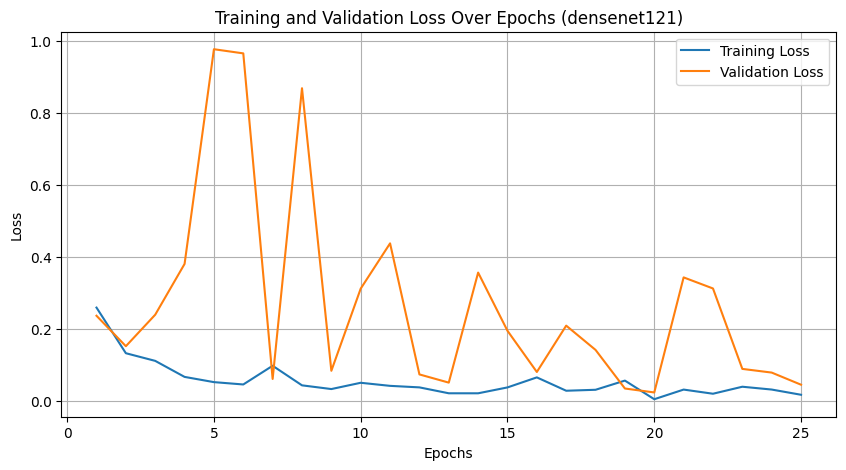

In [4]:
import torch
import matplotlib.pyplot as plt

# Load the saved metrics
metrics_path = "/teamspace/studios/this_studio/.lightning_studio/densenet121_metrics.pth"  # Replace with your actual path
metrics = torch.load(metrics_path)

train_losses = metrics['train_losses']
val_losses = metrics['val_losses']
val_accuracies = metrics['val_accuracies']

# Plot training and validation losses
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs (densenet121)')
plt.legend()
plt.grid()
plt.show()

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import torch
import matplotlib.pyplot as plt

def evaluate_and_plot_confusion_matrix(model, data_loader, device, class_names, title="Confusion Matrix"):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
    
    # Plot confusion matrix with custom title
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()
    
    # Print classification report for additional metrics
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Example usage:
# class_names = ['Glioma', 'Meningioma', 'Tumor']
# evaluate_and_plot_confusion_matrix(model, test_loader, device, class_names, title="Confusion Matrix for Brain Cancer Model")


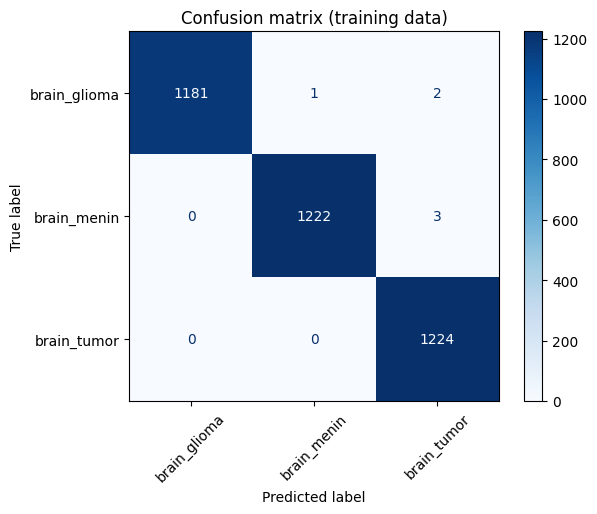

Classification Report:

              precision    recall  f1-score   support

brain_glioma       1.00      1.00      1.00      1184
 brain_menin       1.00      1.00      1.00      1225
 brain_tumor       1.00      1.00      1.00      1224

    accuracy                           1.00      3633
   macro avg       1.00      1.00      1.00      3633
weighted avg       1.00      1.00      1.00      3633

None


In [6]:
class_names = ["brain_glioma", "brain_menin", "brain_tumor"]  # Replace with your actual class names
print(evaluate_and_plot_confusion_matrix(model, train_loader, device, class_names, title="Confusion matrix (training data)")) #confusion matrix for training data

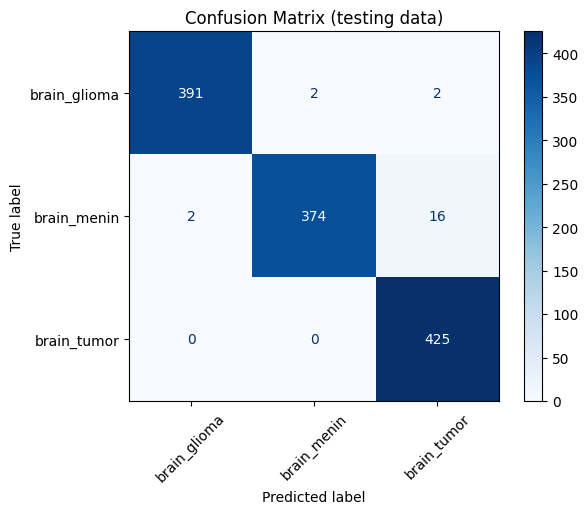

Classification Report:

              precision    recall  f1-score   support

brain_glioma       0.99      0.99      0.99       395
 brain_menin       0.99      0.95      0.97       392
 brain_tumor       0.96      1.00      0.98       425

    accuracy                           0.98      1212
   macro avg       0.98      0.98      0.98      1212
weighted avg       0.98      0.98      0.98      1212

None


In [7]:
print(evaluate_and_plot_confusion_matrix(model, test_loader, device, class_names, title="Confusion Matrix (testing data)"))#test data

In [8]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_precision_recall_curve(model, data_loader, device, class_names):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    # Binarize the labels for multi-class Precision-Recall curve
    all_labels = label_binarize(all_labels, classes=range(len(class_names)))
    all_probs = np.array(all_probs)
    
    # Plot Precision-Recall curve for each class
    plt.figure(figsize=(10, 7))
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_probs[:, i])
        plt.plot(recall, precision, label=f'{class_names[i]}')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for Each Class')
    plt.legend()
    plt.grid()
    plt.show()

# Example usage:
# plot_precision_recall_curve(model, test_loader, device, class_names=['Glioma', 'Meningioma', 'Tumor'])


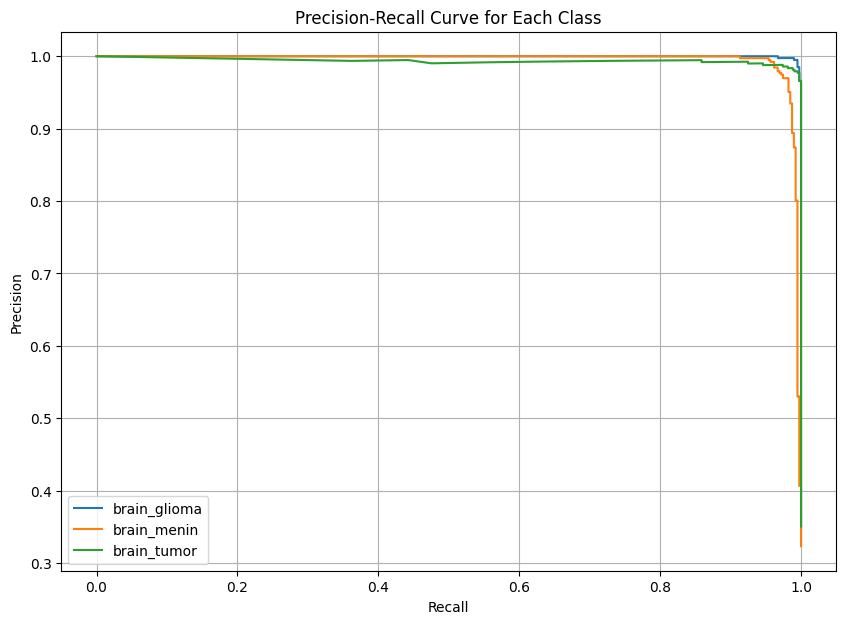

In [9]:
plot_precision_recall_curve(model, test_loader, device, class_names)

In [10]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, data_loader, device, class_names):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    # Binarize the labels for multi-class ROC curve
    all_labels = label_binarize(all_labels, classes=range(len(class_names)))
    all_probs = np.array(all_probs)
    
    # Plot ROC curve for each class
    plt.figure(figsize=(10, 7))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Each Class')
    plt.legend(loc="lower right")
    plt.show()

# Example usage:
# plot_roc_curve(model, test_loader, device, class_names=['Glioma', 'Meningioma', 'Tumor'])


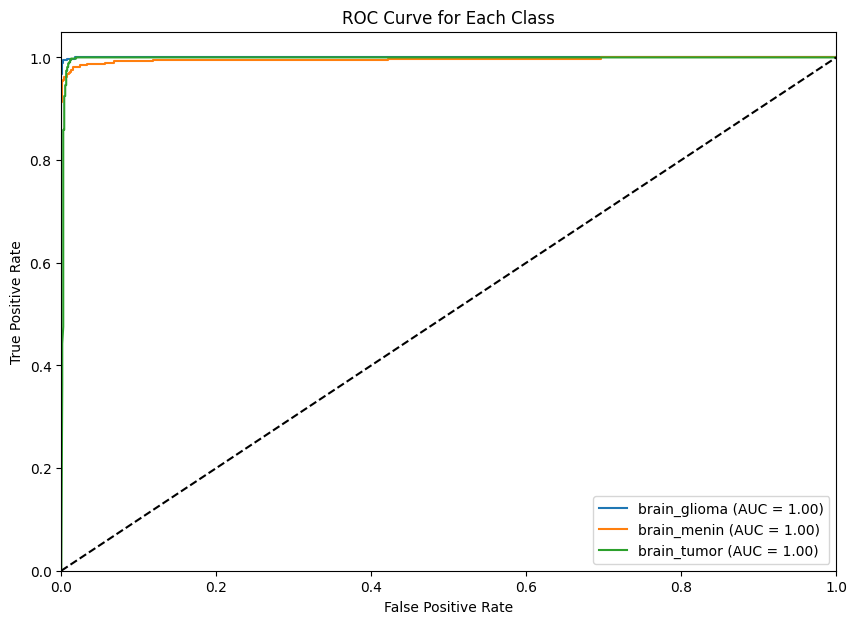

In [11]:
plot_roc_curve(model, test_loader, device, class_names)

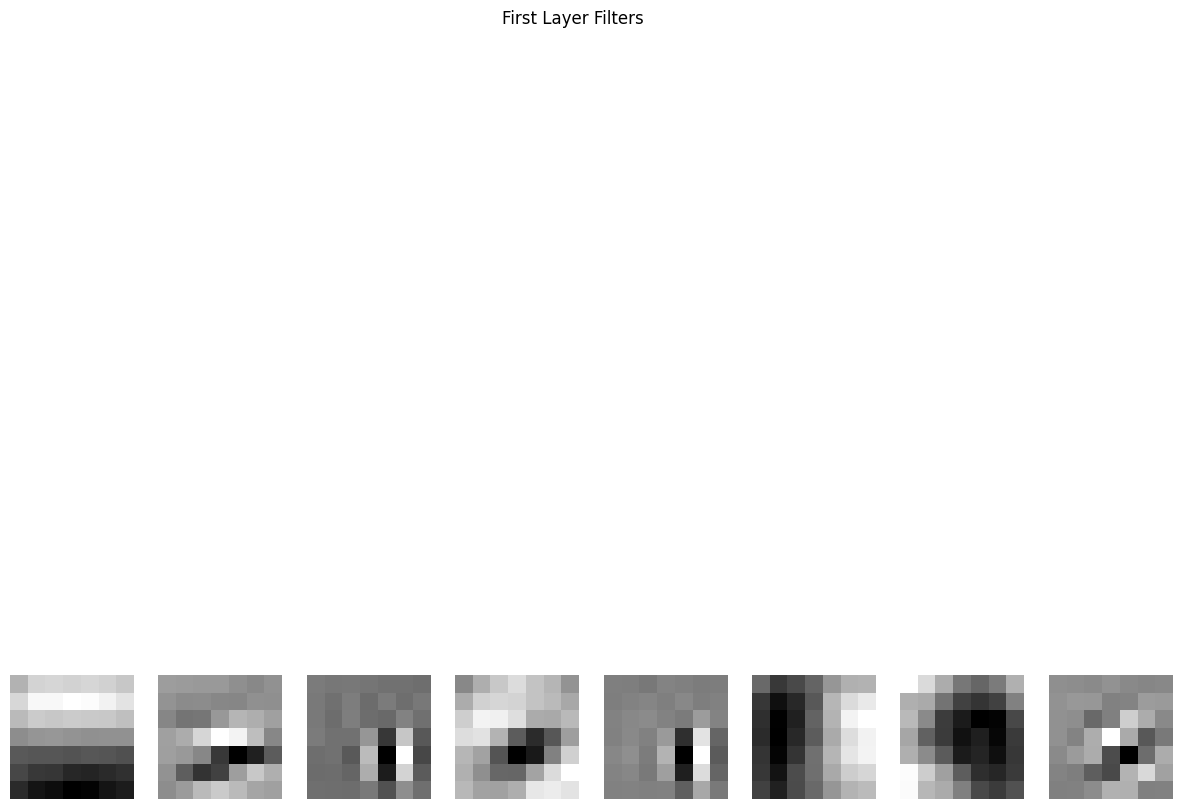

In [12]:
import matplotlib.pyplot as plt

def visualize_filters(layer, num_filters=8):
    filters = layer.weight.data.clone()
    filters = (filters - filters.min()) / (filters.max() - filters.min())  # Normalize to [0,1]
    
    fig, axes = plt.subplots(1, num_filters, figsize=(15, 15))
    for i in range(num_filters):
        filter = filters[i, 0].cpu().numpy()  # Select the first channel of each filter
        axes[i].imshow(filter, cmap='gray')
        axes[i].axis('off')
    plt.suptitle("First Layer Filters")
    plt.show()

# Example usage with VGG16
visualize_filters(model.features[0], num_filters=8)  # Use model.features[0] for the first convolutional layer in VGG16



In [2]:
import gradio as gr
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os

# Load the model
model_path = r"C:\Users\Dell\Desktop\Fall 2024\Machine learning\ML Project\brain_cancer_densenet121.pth"  # Replace with the actual path to your saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model structure (adjust to match your trained model's structure)
from torchvision import models

model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = torch.nn.Linear(num_ftrs, 3)  # Adjust for 3 classes
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# Define the transformation for input images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Class names
class_names = ["Glioma", "Meningioma", "Tumor"]

# Prediction function
def predict_image(image, model, device):
    # Apply transformations
    image = transform(image).unsqueeze(0).to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(image)
        probabilities = F.softmax(outputs, dim=1).cpu().numpy().flatten()
    
    # Get prediction and confidence
    predicted_class = class_names[probabilities.argmax()]
    confidence_percentage = probabilities.max() * 100

    return predicted_class, confidence_percentage, f"{confidence_percentage:.2f}%"

# Gradio interface
iface = gr.Interface(
    fn=lambda image: predict_image(image, model, device),  # Use the prediction function
    inputs=gr.Image(type="pil"),  # Input type
    outputs=[
        gr.Label(label="Classification", elem_id="classification_label"),  # Classification output
        gr.Slider(minimum=0, maximum=100, step=1, label="Confidence", elem_id="black_slider"),  # Confidence slider
        gr.Label(label="Confidence Percentage", elem_id="confidence_percentage"),  # Confidence percentage output
    ],
    title="Welcome to the Brain Cancer Detection Model",
    description="This Model is designed to assist in classifying brain cancer types. Upload an MRI image below and press submit for an evaluation."
)

# Custom CSS for larger font size and black slider
iface.css = """
    #classification_label {font-size: 24px; font-weight: bold;}  /* Larger font for classification */
    #black_slider .slider {background-color: black;}  /* Color the slider black */
"""

# Launch the Gradio interface
iface.launch(share=True)



c:\Users\Dell\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\Dell\AppData\Local\Temp\ipykernel_19056\1463038204.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped 

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4042c833c8a494c724.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
